In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('adult_with_headers (1).csv')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [6]:
df_numeric= df._get_numeric_data()

In [7]:
df_numeric.columns

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

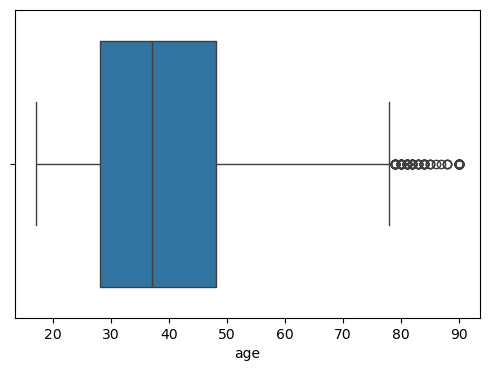

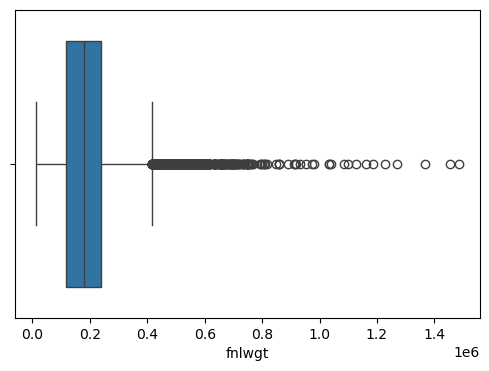

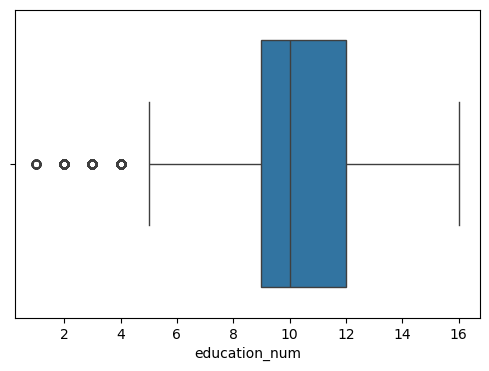

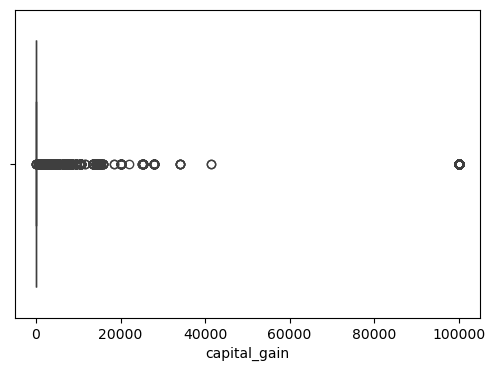

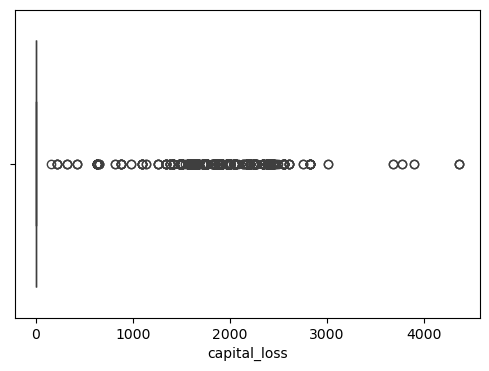

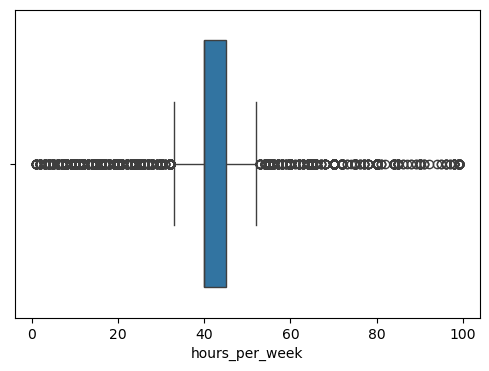

In [8]:
col=['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week']
for i in col :
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_numeric[i])

## Standard Scaler

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standard = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=df_numeric.columns
)

df_standard.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


## Min Max Scaler

In [10]:
df_numeric1= df._get_numeric_data()

In [11]:
from sklearn.preprocessing import MinMaxScaler
mmscaler = MinMaxScaler()

df_standard1 = pd.DataFrame(
    scaler.fit_transform(df_numeric1),
    columns=df_numeric.columns
)

df_standard1.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [12]:
df_copy = df

In [13]:
df_copy.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## one hot encoding

In [14]:
df_copy.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [15]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

workclass 9
education 16
marital_status 7
occupation 15
relationship 6
race 5
sex 2
native_country 42
income 2


In [16]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
encoded = ohe.fit_transform(df[['sex', 'race','income']])
encoded.toarray()

array([[0., 1., 0., ..., 1., 1., 0.],
       [0., 1., 0., ..., 1., 1., 0.],
       [0., 1., 0., ..., 1., 1., 0.],
       ...,
       [1., 0., 0., ..., 1., 1., 0.],
       [0., 1., 0., ..., 1., 1., 0.],
       [1., 0., 0., ..., 1., 0., 1.]], shape=(32561, 9))

In [17]:
ohe.get_feature_names_out(['sex', 'race','income'])

array(['sex_ Female', 'sex_ Male', 'race_ Amer-Indian-Eskimo',
       'race_ Asian-Pac-Islander', 'race_ Black', 'race_ Other',
       'race_ White', 'income_ <=50K', 'income_ >50K'], dtype=object)

In [18]:
encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=ohe.get_feature_names_out(['sex', 'race','income'])
)

In [19]:
encoded_df.head()

,sex_ Female,sex_ Male,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,income_ <=50K,income_ >50K
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [20]:
df_copy = pd.concat(
    [df_copy.drop(['sex', 'race','income'], axis=1),
     encoded_df],
    axis=1
)

In [21]:
df_copy.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,native_country,sex_ Female,sex_ Male,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,income_ <=50K,income_ >50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,...,United-States,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,...,United-States,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,...,United-States,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,...,United-States,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,...,Cuba,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## label encoder

In [22]:
df_copy1= df

In [23]:
df_copy1.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [24]:
from sklearn.preprocessing import LabelEncoder

lab = LabelEncoder()
df_copy1['sex'] = lab.fit_transform(df['sex'])
df_copy1['income'] = lab.fit_transform(df['income'])
df_copy1['race'] = lab.fit_transform(df['race'])


In [25]:
df_copy1.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,4,1,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,4,1,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,4,1,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,2,1,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,2,0,0,0,40,Cuba,0


In [26]:
df_copy1['race'].value_counts

<bound method IndexOpsMixin.value_counts of 0        4
1        4
2        4
3        2
4        2
        ..
32556    4
32557    4
32558    4
32559    4
32560    4
Name: race, Length: 32561, dtype: int64>

In [27]:
df_copy.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,native_country,sex_ Female,sex_ Male,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,income_ <=50K,income_ >50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,...,United-States,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,...,United-States,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,...,United-States,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,...,United-States,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,...,Cuba,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [28]:
df_copy.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,sex_ Female,sex_ Male,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,income_ <=50K,income_ >50K
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456,0.330795,0.669205,0.009551,0.031909,0.095943,0.008323,0.854274,0.759190,0.240810
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429,0.470506,0.470506,0.097264,0.175761,0.294518,0.090851,0.352837,0.427581,0.427581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       32561 non-null  int64  
 1   workclass                 32561 non-null  object 
 2   fnlwgt                    32561 non-null  int64  
 3   education                 32561 non-null  object 
 4   education_num             32561 non-null  int64  
 5   marital_status            32561 non-null  object 
 6   occupation                32561 non-null  object 
 7   relationship              32561 non-null  object 
 8   capital_gain              32561 non-null  int64  
 9   capital_loss              32561 non-null  int64  
 10  hours_per_week            32561 non-null  int64  
 11  native_country            32561 non-null  object 
 12  sex_ Female               32561 non-null  float64
 13  sex_ Male                 32561 non-null  float64
 14  race_ 

In [30]:
df_copy1.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,4,1,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,4,1,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,4,1,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,2,1,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,2,0,0,0,40,Cuba,0


In [31]:
df_copy1.describe()

,age,fnlwgt,education_num,race,sex,capital_gain,capital_loss,hours_per_week,income
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,3.665858,0.669205,1077.648844,87.303830,40.437456,0.240810
std,13.640433,1.055500e+05,2.572720,0.848806,0.470506,7385.292085,402.960219,12.347429,0.427581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,4.000000,0.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,4.000000,1.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,4.000000,1.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,1.000000


In [32]:
df_copy1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  int64 
 9   sex             32561 non-null  int64 
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  int64 
dtypes: int64(9), object(6)
memory usage: 3.7+ MB


## feature engineering


In [33]:
dg= df

In [38]:
dg.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_1
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,4,2174,0,40,United-States,0,True
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,4,0,0,13,United-States,0,True
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,4,0,0,40,United-States,0,True
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,2,0,0,40,United-States,0,True
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,2,0,0,40,Cuba,0,False


In [35]:
dg = pd.get_dummies(dg,columns = ['sex'],drop_first=True)

In [36]:
dg.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_1
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,4,2174,0,40,United-States,0,True
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,4,0,0,13,United-States,0,True
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,4,0,0,40,United-States,0,True
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,2,0,0,40,United-States,0,True
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,2,0,0,40,Cuba,0,False


In [37]:
dg.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_1
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,4,2174,0,40,United-States,0,True
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,4,0,0,13,United-States,0,True
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,4,0,0,40,United-States,0,True
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,2,0,0,40,United-States,0,True
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,2,0,0,40,Cuba,0,False


In [40]:
df['profit'] = df['capital_gain'] - df['capital_loss']

In [42]:
df['work_experience_score'] = df['age'] * df['hours_per_week']

In [43]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,profit,work_experience_score
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,4,1,2174,0,40,United-States,0,2174,1560
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,4,1,0,0,13,United-States,0,0,650
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,4,1,0,0,40,United-States,0,0,1520
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,2,1,0,0,40,United-States,0,0,2120
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,2,0,0,0,40,Cuba,0,0,1120


In [44]:
df_numeric.skew()

age                0.558743
fnlwgt             1.446980
education_num     -0.311676
capital_gain      11.953848
capital_loss       4.594629
hours_per_week     0.227643
dtype: float64

In [45]:
import numpy as np

df['capital_gain_log'] = np.log1p(df['capital_gain'])

In [46]:
df['capital_gain_log'].skew()

np.float64(3.096143524467517)